# Step 5 — SVM Signal Peptide Classifier
**LB2 Project · Group 7 · Signal Peptide Prediction**

### Objective
Train a **Support Vector Machine (SVM)** classifier for signal peptide detection using
biochemical features extracted from the N-terminal region of each protein.

### Pipeline
1. Load the predefined training/benchmark splits and restrict sequences to the **filtered non-redundant accession set**
2. Extract biochemical features from the N-terminal region of each sequence
3. For outer-fold cross-validation:
   - optionally select top features using **Random Forest importance on the outer-training split only**
   - standardise features using **z-score scaling fit on outer-training only**
   - tune RBF-kernel SVM hyperparameters (**C**, **γ**) by **inner cross-validation**, optimising **MCC**
   - evaluate on the held-out outer fold to obtain **out-of-fold (OOF)** predictions
4. Compare two settings:
   - **all features**
   - **selected features**
5. Select final hyperparameters on the **full training set** by 5-fold CV
6. Retrain on the full training set and evaluate once on the **held-out benchmark set**

### Features extracted
| Feature group | Description | Region |
|---|---|---|
| AA composition | Frequency of each of 20 amino acids | First 20 aa |
| Hydrophobicity | Max and avg (Kyte-Doolittle, window=5) | First 40 aa |
| Charge | Max abundance of K/R and its normalised position (window=3) | First 40 aa |
| α-helix propensity | Max and avg (Chou-Fasman, window=7) | First 40 aa |
| TM propensity | Max and avg (Kyte scale, window=7) | First 40 aa |

**Total: 28 features** (20 composition + 2 hydrophobicity + 2 charge + 2 α-helix + 2 TM)

### Input files
- `training_with_folds.tsv`
- `benchmarking_set.tsv`
- `filtered_positive.tsv`
- `filtered_negative.tsv`
- `positive.fasta`
- `negative.fasta`

### Output files
- `figures/svm_feature_importance.pdf/.png`
- `figures/svm_cv_pr_roc_all.pdf/.png`
- `figures/svm_*.pdf/.png` — confusion matrices and related benchmark figures
- Console summary: OOF CV metrics + benchmark metrics

---
## Cell 1 — Install dependencies

In [5]:
!pip install -q biopython pandas numpy scikit-learn matplotlib seaborn
print('Done.')

Done.


---
## Cell 2 — Imports, scales, and constants

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    matthews_corrcoef, f1_score, accuracy_score,
    precision_score, recall_score, confusion_matrix
)
from sklearn.model_selection import ParameterGrid
import warnings
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.1)

# --- Biochemical scales ---

# Kyte-Doolittle hydrophobicity
HYDROPATHY = {
    'A':  1.80, 'C':  2.50, 'D': -3.50, 'E': -3.50, 'F':  2.80,
    'G': -0.40, 'H': -3.20, 'I':  4.50, 'K': -3.90, 'L':  3.80,
    'M':  1.90, 'N': -3.50, 'P': -1.60, 'Q': -3.50, 'R': -4.50,
    'S': -0.80, 'T': -0.70, 'V':  4.20, 'W': -0.90, 'Y': -1.30
}

# Positive charge indicator (K, R = 1, others = 0)
CHARGE = {
    'A': 0, 'C': 0, 'D': 0, 'E': 0, 'F': 0,
    'G': 0, 'H': 0, 'I': 0, 'K': 1, 'L': 0,
    'M': 0, 'N': 0, 'P': 0, 'Q': 0, 'R': 1,
    'S': 0, 'T': 0, 'V': 0, 'W': 0, 'Y': 0
}

# Chou-Fasman alpha-helix propensity
ALPHA_HELIX = {
    'A': 1.42, 'C': 0.70, 'D': 1.01, 'E': 1.51, 'F': 1.13,
    'G': 0.57, 'H': 1.00, 'I': 1.08, 'K': 1.16, 'L': 1.21,
    'M': 1.45, 'N': 0.67, 'P': 0.57, 'Q': 1.11, 'R': 0.98,
    'S': 0.77, 'T': 0.83, 'V': 1.06, 'W': 1.08, 'Y': 0.69
}

# Transmembrane tendency (Kyte scale adapted)
TM_TENDENCY = {
    'A':  0.38, 'C': -0.30, 'D': -3.27, 'E': -2.90, 'F':  1.98,
    'G': -0.19, 'H': -1.44, 'I':  1.97, 'K': -3.46, 'L':  1.82,
    'M':  1.40, 'N': -1.62, 'P': -1.44, 'Q': -1.84, 'R': -2.57,
    'S': -0.53, 'T': -0.32, 'V':  1.46, 'W':  1.53, 'Y':  0.49
}

AA_LIST = sorted(HYDROPATHY.keys())  # 20 standard amino acids, alphabetical

print('Imports and scales loaded.')
print(f'Feature groups: AA composition (20) + hydrophobicity (2) + charge (2) + alpha-helix (2) + TM (2) = 28 total')

Imports and scales loaded.
Feature groups: AA composition (20) + hydrophobicity (2) + charge (2) + alpha-helix (2) + TM (2) = 28 total


---
## Cell 3 — Feature extraction functions

In [7]:
def sliding_window_values(values, window_size):
    """Return list of sliding window sums/averages over a list of values."""
    if len(values) < window_size:
        return []
    return [values[i:i+window_size] for i in range(len(values) - window_size + 1)]


def extract_features(seq):
    """
    Extract all 28 features from a protein sequence.

    All features are computed from the N-terminal region only,
    since signal peptides are always N-terminal.

    Returns a dict of feature_name -> float.
    """
    seq = seq.upper()
    features = {}

    # --- 1. Amino acid composition (first 20 aa) ---
    region = seq[:20]
    total  = len(region)
    for aa in AA_LIST:
        features[f'comp_{aa}'] = region.count(aa) / total if total > 0 else 0.0

    # --- 2. Hydrophobicity (first 40 aa, window=5) ---
    region40 = seq[:40]
    hydro_vals = [HYDROPATHY.get(aa, 0.0) for aa in region40]
    windows = sliding_window_values(hydro_vals, 5)
    if windows:
        window_sums = [sum(w) for w in windows]
        features['max_hydrophobicity'] = max(window_sums)
        features['avg_hydrophobicity'] = float(np.mean(window_sums))
    else:
        features['max_hydrophobicity'] = 0.0
        features['avg_hydrophobicity'] = 0.0

    # --- 3. Charge features (first 40 aa, window=3) ---
    charge_vals = [CHARGE.get(aa, 0) for aa in region40]
    windows = sliding_window_values(charge_vals, 3)
    if windows:
        window_sums = [sum(w) for w in windows]
        max_charge = max(window_sums)
        features['max_charge_abundance'] = float(max_charge)
        if max_charge > 0:
            max_idx = window_sums.index(max_charge)
            features['pos_max_charge'] = (max_idx + 1) / len(window_sums)
        else:
            features['pos_max_charge'] = 0.0
    else:
        features['max_charge_abundance'] = 0.0
        features['pos_max_charge'] = 0.0

    # --- 4. Alpha-helix propensity (first 40 aa, window=7) ---
    alpha_vals = [ALPHA_HELIX.get(aa, 0.0) for aa in region40]
    windows = sliding_window_values(alpha_vals, 7)
    if windows:
        window_avgs = [float(np.mean(w)) for w in windows]
        features['avg_alpha_propensity'] = float(np.mean(window_avgs))
        features['max_alpha_propensity'] = max(window_avgs)
    else:
        features['avg_alpha_propensity'] = 0.0
        features['max_alpha_propensity'] = 0.0

    # --- 5. Transmembrane propensity (first 40 aa, window=7) ---
    tm_vals = [TM_TENDENCY.get(aa, 0.0) for aa in region40]
    windows = sliding_window_values(tm_vals, 7)
    if windows:
        window_avgs = [float(np.mean(w)) for w in windows]
        features['avg_tm_propensity'] = float(np.mean(window_avgs))
        features['max_tm_propensity'] = max(window_avgs)
    else:
        features['avg_tm_propensity'] = 0.0
        features['max_tm_propensity'] = 0.0

    return features


# Quick sanity check
test_feat = extract_features('MKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY')
print(f'Features per sequence: {len(test_feat)}')
print(f'Feature names: {list(test_feat.keys())}')

Features per sequence: 28
Feature names: ['comp_A', 'comp_C', 'comp_D', 'comp_E', 'comp_F', 'comp_G', 'comp_H', 'comp_I', 'comp_K', 'comp_L', 'comp_M', 'comp_N', 'comp_P', 'comp_Q', 'comp_R', 'comp_S', 'comp_T', 'comp_V', 'comp_W', 'comp_Y', 'max_hydrophobicity', 'avg_hydrophobicity', 'max_charge_abundance', 'pos_max_charge', 'avg_alpha_propensity', 'max_alpha_propensity', 'avg_tm_propensity', 'max_tm_propensity']


---
## Cell 4 — Load data and build feature matrix

In [8]:
# Load metadata
df_train = pd.read_csv('training_with_folds.tsv', sep='\t')
df_bench = pd.read_csv('benchmarking_set.tsv', sep='\t')
df_pos_filtered = pd.read_csv('filtered_positive.tsv', sep='\t')
df_neg_filtered = pd.read_csv('filtered_negative.tsv', sep='\t')

# Restrict sequence source to filtered accessions only
filtered_accessions = set(df_pos_filtered['Accession']).union(set(df_neg_filtered['Accession']))

all_seqs = {}
for rec in SeqIO.parse('positive.fasta', 'fasta'):
    if rec.id in filtered_accessions:
        all_seqs[rec.id] = str(rec.seq)
for rec in SeqIO.parse('negative.fasta', 'fasta'):
    if rec.id in filtered_accessions:
        all_seqs[rec.id] = str(rec.seq)

print(f'Filtered sequences loaded: {len(all_seqs):,}')

# Sanity checks
train_missing = sorted(set(df_train['Accession']) - set(all_seqs.keys()))
bench_missing = sorted(set(df_bench['Accession']) - set(all_seqs.keys()))
assert len(train_missing) == 0, f'Missing training sequences: {train_missing[:5]}'
assert len(bench_missing) == 0, f'Missing benchmark sequences: {bench_missing[:5]}'

def build_feature_matrix(df, all_seqs):
    """Extract features for all sequences in df. Returns feature dataframe and feature column names."""
    records = []
    for _, row in df.iterrows():
        seq = all_seqs.get(row['Accession'], '')
        if not seq:
            continue
        feat = extract_features(seq)
        feat['label'] = row['label']
        feat['Accession'] = row['Accession']
        if 'fold' in df.columns:
            feat['fold'] = row['fold']
        records.append(feat)

    feat_df = pd.DataFrame(records)
    meta_cols = ['label', 'Accession'] + (['fold'] if 'fold' in feat_df.columns else [])
    feature_cols = [c for c in feat_df.columns if c not in meta_cols]
    return feat_df, feature_cols

print('Extracting training features...')
train_feat_df, FEATURE_COLS = build_feature_matrix(df_train, all_seqs)
print('Extracting benchmark features...')
bench_feat_df, _ = build_feature_matrix(df_bench, all_seqs)

print(f'\nTraining feature matrix : {train_feat_df.shape}')
print(f'Benchmark feature matrix: {bench_feat_df.shape}')
print(f'Number of features      : {len(FEATURE_COLS)}')

Filtered sequences loaded: 10,027
Extracting training features...
Extracting benchmark features...

Training feature matrix : (8021, 31)
Benchmark feature matrix: (2006, 30)
Number of features      : 28


---
## Cell 5 — Feature selection via Random Forest importance

We use a Random Forest trained on each training fold to rank feature importance.
The average importance across all folds determines which features are selected.
This prevents data leakage — the feature selector only sees training data.

Top 20 features by Random Forest importance (training set only):
             feature  importance
   max_tm_propensity    0.254389
  max_hydrophobicity    0.116729
   avg_tm_propensity    0.111262
  avg_hydrophobicity    0.110621
              comp_L    0.096124
      pos_max_charge    0.030067
max_alpha_propensity    0.026362
avg_alpha_propensity    0.024596
              comp_A    0.023526
              comp_E    0.023458
              comp_D    0.021246
              comp_R    0.013740
              comp_N    0.012868
              comp_G    0.012221
              comp_V    0.012013
              comp_F    0.011519
              comp_P    0.010705
max_charge_abundance    0.010432
              comp_S    0.010247
              comp_C    0.009679


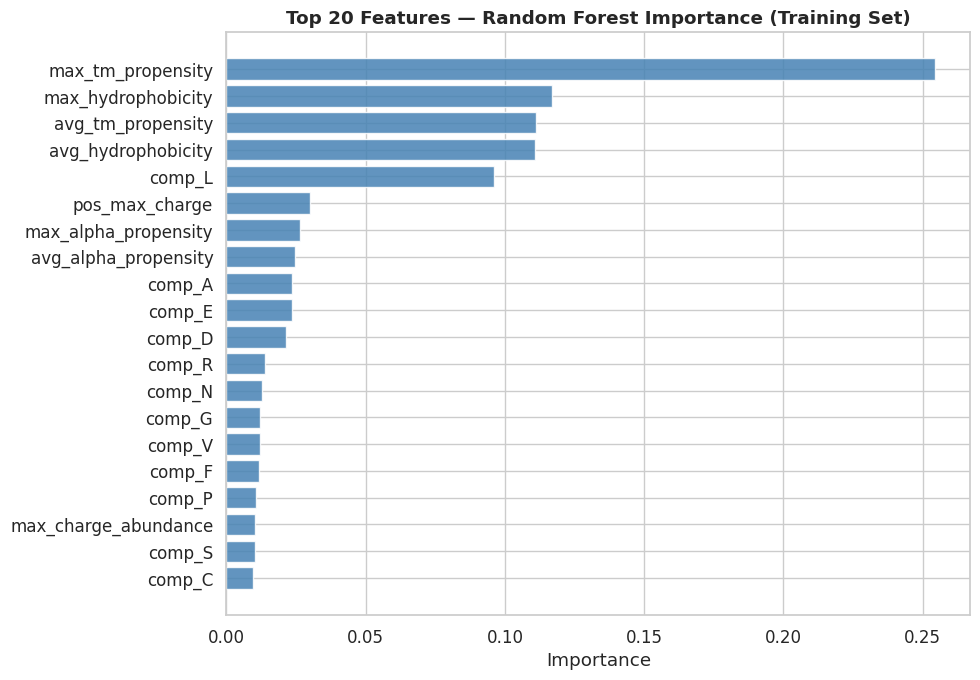

Saved: figures/svm_feature_importance.pdf/.png


In [9]:
folds = sorted(train_feat_df['fold'].unique())
N_TOP = 20

def select_top_features_rf(df_train_part, feature_cols, n_top=20, random_state=42):
    """
    Select top features using Random Forest trained ONLY on the provided training subset.
    """
    X = df_train_part[feature_cols].values
    y = df_train_part['label'].values
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X, y)
    importances = rf.feature_importances_
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    top_features = importance_df['feature'].head(n_top).tolist()
    return top_features, importance_df

# Final training-set-only feature ranking for reporting/final model
TOP_FEATURES_FINAL, importance_df = select_top_features_rf(train_feat_df, FEATURE_COLS, n_top=N_TOP)

print(f'Top {N_TOP} features by Random Forest importance (training set only):')
print(importance_df.head(N_TOP).to_string(index=False))

# Plot feature importances for reporting
fig, ax = plt.subplots(figsize=(10, 7))
top_df = importance_df.head(N_TOP)
ax.barh(top_df['feature'][::-1], top_df['importance'][::-1], color='steelblue', alpha=0.85)
ax.set_xlabel('Importance')
ax.set_title(f'Top {N_TOP} Features — Random Forest Importance (Training Set)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/svm_feature_importance.pdf', bbox_inches='tight')
plt.savefig('figures/svm_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/svm_feature_importance.pdf/.png')

---
## Cell 6 — 5-fold CV with grid search (ALL features)

For each fold:
- Fit a `StandardScaler` on training folds only (no leakage)
- Grid search over C and γ using MCC as the optimisation metric
- Evaluate on the validation fold

In [10]:
# Hyperparameter grid
PARAM_GRID = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001]
}

def inner_cv_select_params(df_train_outer, feature_cols, inner_folds, param_grid):
    """
    Choose hyperparameters using INNER CV on the outer-training split only.
    """
    best_mean_mcc = -2
    best_params = None

    for params in ParameterGrid(param_grid):
        inner_mccs = []

        for inner_val_fold in inner_folds:
            df_inner_train = df_train_outer[df_train_outer['fold'] != inner_val_fold]
            df_inner_val   = df_train_outer[df_train_outer['fold'] == inner_val_fold]

            X_tr = df_inner_train[feature_cols].values
            y_tr = df_inner_train['label'].values
            X_val = df_inner_val[feature_cols].values
            y_val = df_inner_val['label'].values

            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr)
            X_val_sc = scaler.transform(X_val)

            svm = SVC(kernel='rbf', probability=True, random_state=42, **params)
            svm.fit(X_tr_sc, y_tr)
            preds = svm.predict(X_val_sc)

            inner_mccs.append(matthews_corrcoef(y_val, preds))

        mean_mcc = np.mean(inner_mccs)
        if mean_mcc > best_mean_mcc:
            best_mean_mcc = mean_mcc
            best_params = params

    return best_params, best_mean_mcc


def run_svm_nested_cv(train_feat_df, feature_cols, outer_folds, param_grid, feature_mode='all', n_top=20):
    """
    Leakage-free outer CV with inner CV hyperparameter tuning.
    If feature_mode='selected', top features are selected inside each outer fold using outer-train only.
    Returns pooled OOF scores/preds/labels and per-fold metadata.
    """
    oof_scores = np.full(len(train_feat_df), np.nan, dtype=float)
    oof_preds  = np.full(len(train_feat_df), -1, dtype=int)
    oof_labels = train_feat_df['label'].to_numpy()

    best_params_list = []
    selected_feature_sets = []
    fold_rows = []

    print(f'{"Fold":<6} {"Mode":<10} {"#Feat":<8} {"Best C":<8} {"Best γ":<10} {"Outer MCC":<10} {"Outer F1":<10}')
    print('-' * 76)

    for outer_val_fold in outer_folds:
        outer_train_mask = train_feat_df['fold'] != outer_val_fold
        outer_val_mask   = train_feat_df['fold'] == outer_val_fold

        df_outer_train = train_feat_df.loc[outer_train_mask]
        df_outer_val   = train_feat_df.loc[outer_val_mask]

        # Feature selection ONLY on outer-training data
        if feature_mode == 'selected':
            outer_feature_cols, _ = select_top_features_rf(df_outer_train, feature_cols, n_top=n_top)
            selected_feature_sets.append(outer_feature_cols)
        else:
            outer_feature_cols = list(feature_cols)

        # Inner CV for parameter selection using only outer-training folds
        inner_folds = sorted(df_outer_train['fold'].unique())
        best_params, inner_mean_mcc = inner_cv_select_params(
            df_outer_train, outer_feature_cols, inner_folds, param_grid
        )

        # Fit final outer-fold model
        X_tr = df_outer_train[outer_feature_cols].values
        y_tr = df_outer_train['label'].values
        X_val = df_outer_val[outer_feature_cols].values
        y_val = df_outer_val['label'].values

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_val_sc = scaler.transform(X_val)

        svm = SVC(kernel='rbf', probability=True, random_state=42, **best_params)
        svm.fit(X_tr_sc, y_tr)

        fold_probs = svm.predict_proba(X_val_sc)[:, 1]
        fold_preds = svm.predict(X_val_sc)

        oof_scores[outer_val_mask.to_numpy()] = fold_probs
        oof_preds[outer_val_mask.to_numpy()] = fold_preds

        outer_mcc = matthews_corrcoef(y_val, fold_preds)
        outer_f1  = f1_score(y_val, fold_preds, zero_division=0)

        best_params_list.append(best_params)
        fold_rows.append({
            'fold': outer_val_fold,
            'n_features': len(outer_feature_cols),
            'best_C': best_params['C'],
            'best_gamma': best_params['gamma'],
            'inner_mean_mcc': inner_mean_mcc,
            'outer_mcc': outer_mcc,
            'outer_f1': outer_f1,
        })

        print(f"{outer_val_fold:<6} {feature_mode:<10} {len(outer_feature_cols):<8} "
              f"{str(best_params['C']):<8} {str(best_params['gamma']):<10} "
              f"{outer_mcc:<10.3f} {outer_f1:<10.3f}")

    assert not np.isnan(oof_scores).any(), "Some OOF scores were not filled."
    assert (oof_preds >= 0).all(), "Some OOF predictions were not filled."

    metrics = {
        'MCC': matthews_corrcoef(oof_labels, oof_preds),
        'Precision': precision_score(oof_labels, oof_preds, zero_division=0),
        'Recall': recall_score(oof_labels, oof_preds, zero_division=0),
        'F1': f1_score(oof_labels, oof_preds, zero_division=0),
        'Accuracy': accuracy_score(oof_labels, oof_preds),
    }

    return {
        'scores': oof_scores,
        'labels': oof_labels,
        'preds': oof_preds,
        'params_list': best_params_list,
        'selected_feature_sets': selected_feature_sets,
        'fold_rows': pd.DataFrame(fold_rows),
        'metrics': metrics,
    }


print('=== SVM with ALL FEATURES ===')
cv_all = run_svm_nested_cv(
    train_feat_df, FEATURE_COLS, folds, PARAM_GRID,
    feature_mode='all', n_top=N_TOP
)

cv_metrics_all = cv_all['metrics']
scores_all = cv_all['scores']
labels_all = cv_all['labels']
preds_all = cv_all['preds']
params_all = cv_all['params_list']

print('\nOOF CV metrics (all features):')
for k, v in cv_metrics_all.items():
    print(f'  {k:<12}: {v:.3f}')

=== SVM with ALL FEATURES ===
Fold   Mode       #Feat    Best C   Best γ     Outer MCC  Outer F1  
----------------------------------------------------------------------------
0      all        28       1        scale      0.869      0.883     
1      all        28       10       0.01       0.826      0.845     
2      all        28       10       0.01       0.859      0.875     
3      all        28       10       0.01       0.836      0.853     
4      all        28       10       0.01       0.870      0.884     

OOF CV metrics (all features):
  MCC         : 0.852
  Precision   : 0.867
  Recall      : 0.870
  F1          : 0.868
  Accuracy    : 0.971


---
## Cell 7 — 5-fold CV with grid search (SELECTED features)

In [11]:
print(f'=== SVM with SELECTED FEATURES (top {N_TOP}) ===')
cv_sel = run_svm_nested_cv(
    train_feat_df, FEATURE_COLS, folds, PARAM_GRID,
    feature_mode='selected', n_top=N_TOP
)

cv_metrics_sel = cv_sel['metrics']
scores_sel = cv_sel['scores']
labels_sel = cv_sel['labels']
preds_sel = cv_sel['preds']
params_sel = cv_sel['params_list']

print('\nOOF CV metrics (selected features):')
for k, v in cv_metrics_sel.items():
    print(f'  {k:<12}: {v:.3f}')

=== SVM with SELECTED FEATURES (top 20) ===
Fold   Mode       #Feat    Best C   Best γ     Outer MCC  Outer F1  
----------------------------------------------------------------------------
0      selected   20       10       0.01       0.870      0.884     
1      selected   20       10       0.01       0.824      0.843     
2      selected   20       1        scale      0.862      0.877     
3      selected   20       10       0.01       0.843      0.860     
4      selected   20       10       0.01       0.868      0.883     

OOF CV metrics (selected features):
  MCC         : 0.853
  Precision   : 0.867
  Recall      : 0.872
  F1          : 0.869
  Accuracy    : 0.971


---
## Cell 8 — CV curves (PR + ROC) for all-feature model

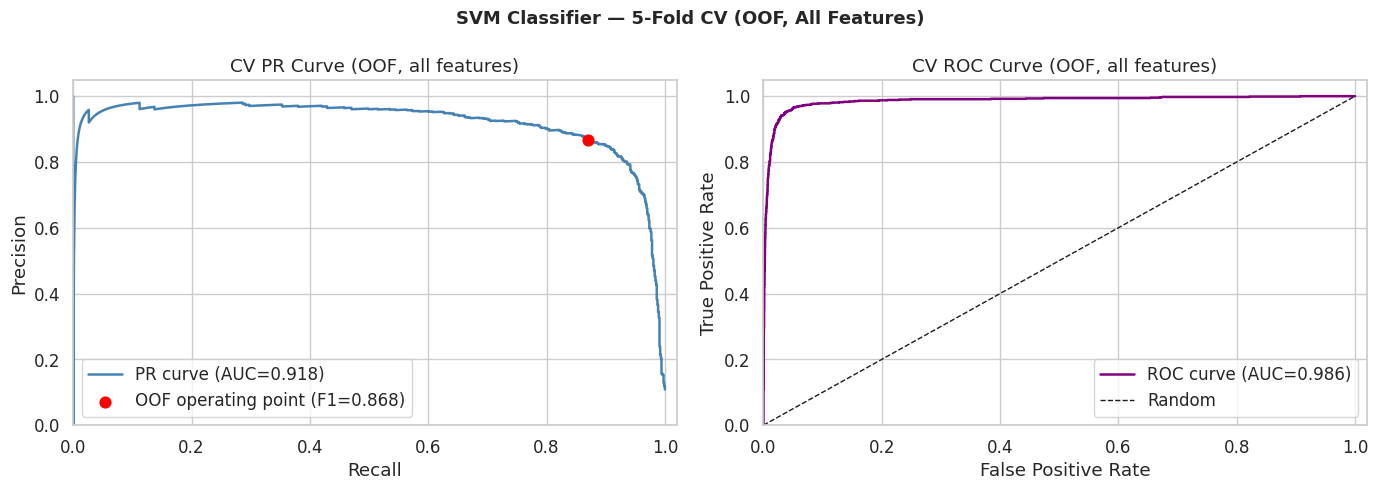

PR AUC=0.918  |  ROC AUC=0.986
Saved: figures/svm_cv_pr_roc_all.pdf/.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve (OOF, all features)
prec, rec, _ = precision_recall_curve(labels_all, scores_all)
pr_auc = auc(rec, prec)
ax = axes[0]
ax.plot(rec, prec, color='steelblue', linewidth=1.8, label=f'PR curve (AUC={pr_auc:.3f})')
ax.scatter([cv_metrics_all['Recall']], [cv_metrics_all['Precision']],
           color='red', s=60, zorder=5,
           label=f'OOF operating point (F1={cv_metrics_all["F1"]:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('CV PR Curve (OOF, all features)')
ax.legend()
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)

# ROC curve (OOF, all features)
fpr, tpr, _ = roc_curve(labels_all, scores_all)
roc_auc = auc(fpr, tpr)
ax2 = axes[1]
ax2.plot(fpr, tpr, color='purple', linewidth=1.8, label=f'ROC curve (AUC={roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('CV ROC Curve (OOF, all features)')
ax2.legend()
ax2.set_xlim(0, 1.02)
ax2.set_ylim(0, 1.05)

plt.suptitle('SVM Classifier — 5-Fold CV (OOF, All Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/svm_cv_pr_roc_all.pdf', bbox_inches='tight')
plt.savefig('figures/svm_cv_pr_roc_all.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PR AUC={pr_auc:.3f}  |  ROC AUC={roc_auc:.3f}')
print('Saved: figures/svm_cv_pr_roc_all.pdf/.png')

---
## Cell 9 — Train final model on full training set + benchmark evaluation

We pick the most common best hyperparameters across folds,
retrain on the **entire** training set, and evaluate on the blind benchmark.

In [13]:
def choose_final_params_full_training(train_feat_df, feature_cols, param_grid):
    """
    Choose final hyperparameters using 5-fold CV on the full training set only.
    """
    inner_folds = sorted(train_feat_df['fold'].unique())
    best_params, best_mean_mcc = inner_cv_select_params(
        train_feat_df, feature_cols, inner_folds, param_grid
    )
    return best_params, best_mean_mcc


def train_and_benchmark(train_feat_df, bench_feat_df, feature_cols, params, label):
    """
    Train final SVM on full training set with params selected via CV on training only.
    Evaluate on benchmark set.
    """
    print(f'[{label}] Final hyperparameters: C={params["C"]}, gamma={params["gamma"]}')

    X_train = train_feat_df[feature_cols].values
    y_train = train_feat_df['label'].values
    X_bench = bench_feat_df[feature_cols].values
    y_bench = bench_feat_df['label'].values

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_bench_sc = scaler.transform(X_bench)

    svm_final = SVC(
        kernel='rbf',
        C=params['C'],
        gamma=params['gamma'],
        probability=True,
        random_state=42
    )
    svm_final.fit(X_train_sc, y_train)

    bench_probs = svm_final.predict_proba(X_bench_sc)[:, 1]
    bench_preds = svm_final.predict(X_bench_sc)

    metrics = {
        'MCC': matthews_corrcoef(y_bench, bench_preds),
        'Precision': precision_score(y_bench, bench_preds, zero_division=0),
        'Recall': recall_score(y_bench, bench_preds, zero_division=0),
        'F1': f1_score(y_bench, bench_preds, zero_division=0),
        'Accuracy': accuracy_score(y_bench, bench_preds),
    }
    return metrics, bench_probs, bench_preds, y_bench, svm_final, scaler


# Final all-feature params selected on full training set only
final_params_all, final_inner_mcc_all = choose_final_params_full_training(
    train_feat_df, FEATURE_COLS, PARAM_GRID
)

bench_metrics_all, bench_probs_all, bench_preds_all, y_bench, model_all, scaler_all = \
    train_and_benchmark(train_feat_df, bench_feat_df, FEATURE_COLS, final_params_all, 'ALL')

print('\nBenchmark metrics (all features):')
for k, v in bench_metrics_all.items():
    print(f'  {k:<12}: {v:.3f}')

# Final selected-feature set and params selected on full training set only
TOP_FEATURES_FINAL, importance_df_final = select_top_features_rf(
    train_feat_df, FEATURE_COLS, n_top=N_TOP
)
final_params_sel, final_inner_mcc_sel = choose_final_params_full_training(
    train_feat_df, TOP_FEATURES_FINAL, PARAM_GRID
)

bench_metrics_sel, bench_probs_sel, bench_preds_sel, _, model_sel, scaler_sel = \
    train_and_benchmark(train_feat_df, bench_feat_df, TOP_FEATURES_FINAL, final_params_sel, 'SELECTED')

print('\nBenchmark metrics (selected features):')
for k, v in bench_metrics_sel.items():
    print(f'  {k:<12}: {v:.3f}')

[ALL] Final hyperparameters: C=1, gamma=scale

Benchmark metrics (all features):
  MCC         : 0.854
  Precision   : 0.872
  Recall      : 0.868
  F1          : 0.870
  Accuracy    : 0.972
[SELECTED] Final hyperparameters: C=10, gamma=0.01

Benchmark metrics (selected features):
  MCC         : 0.846
  Precision   : 0.866
  Recall      : 0.858
  F1          : 0.862
  Accuracy    : 0.970


---
## Cell 10 — Benchmark confusion matrices

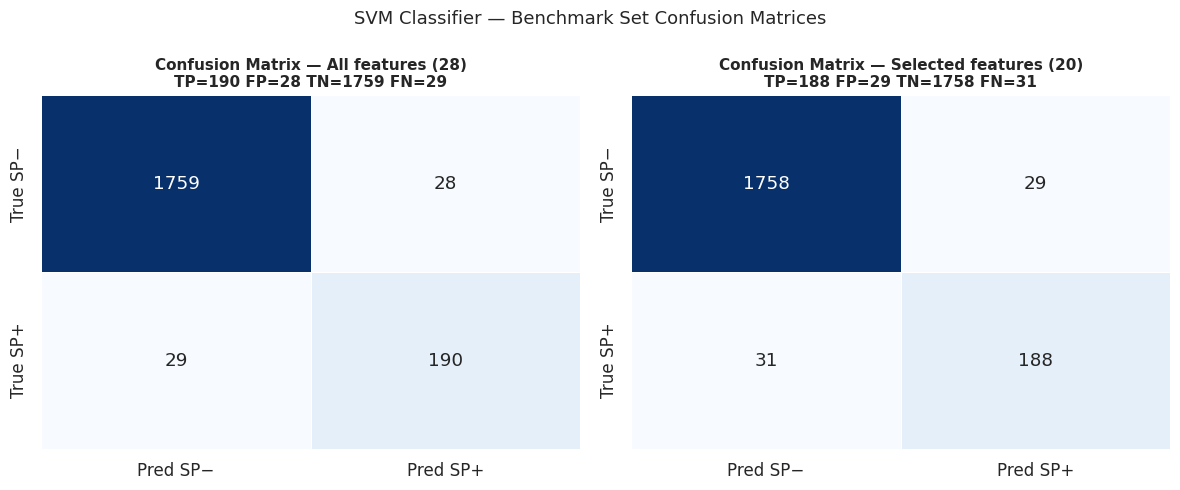

Saved: figures/svm_benchmark_confusion.pdf/.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes,
    [bench_preds_all, bench_preds_sel],
    ['All features (28)', f'Selected features ({N_TOP})']):

    cm = confusion_matrix(y_bench, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred SP−', 'Pred SP+'],
                yticklabels=['True SP−', 'True SP+'],
                linewidths=0.5, cbar=False)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'Confusion Matrix — {title}\nTP={tp} FP={fp} TN={tn} FN={fn}',
                 fontsize=11, fontweight='bold')

plt.suptitle('SVM Classifier — Benchmark Set Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('figures/svm_benchmark_confusion.pdf', bbox_inches='tight')
plt.savefig('figures/svm_benchmark_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/svm_benchmark_confusion.pdf/.png')

---
## Cell 11 — Final summary table

In [15]:
sep = '=' * 66
print(sep)
print('  SVM CLASSIFIER SUMMARY — LB2 Group 7')
print(sep)
print()
print(f'  {"Metric":<14} {"CV (all)":>10} {"Bench (all)":>13} {"CV (sel)":>10} {"Bench (sel)":>13}')
print('  ' + '-' * 62)
for metric in ['MCC', 'Precision', 'Recall', 'F1', 'Accuracy']:
    print(f'  {metric:<14} '
          f'{cv_metrics_all[metric]:>10.3f} '
          f'{bench_metrics_all[metric]:>13.3f} '
          f'{cv_metrics_sel[metric]:>10.3f} '
          f'{bench_metrics_sel[metric]:>13.3f}')
print()
print('  Feature sets')
print(f'    All features      : {len(FEATURE_COLS)}')
print(f'    Selected features : {N_TOP} (RF importance, training set only)')
print(f'    Top selected      : {TOP_FEATURES_FINAL[:5]} ...')
print()
print('  Hyperparameter search')
print(f'    Kernel  : RBF')
print(f'    C grid  : {PARAM_GRID["C"]}')
print(f'    γ grid  : {PARAM_GRID["gamma"]}')
print(f'    Metric  : MCC (inner CV selection)')
print()
print('  Output figures')
for f in sorted(os.listdir('figures')):
    if f.startswith('svm_'):
        print(f'    figures/{f}')
print()
print(sep)

  SVM CLASSIFIER SUMMARY — LB2 Group 7

  Metric           CV (all)   Bench (all)   CV (sel)   Bench (sel)
  --------------------------------------------------------------
  MCC                 0.852         0.854      0.853         0.846
  Precision           0.867         0.872      0.867         0.866
  Recall              0.870         0.868      0.872         0.858
  F1                  0.868         0.870      0.869         0.862
  Accuracy            0.971         0.972      0.971         0.970

  Feature sets
    All features      : 28
    Selected features : 20 (RF importance, training set only)
    Top selected      : ['max_tm_propensity', 'max_hydrophobicity', 'avg_tm_propensity', 'avg_hydrophobicity', 'comp_L'] ...

  Hyperparameter search
    Kernel  : RBF
    C grid  : [0.1, 1, 10]
    γ grid  : ['scale', 0.01, 0.001]
    Metric  : MCC (inner CV selection)

  Output figures
    figures/svm_benchmark_confusion.pdf
    figures/svm_benchmark_confusion.png
    figures/svm_cv_